# 图像特征工程

> **斯坦福 CS231n Assignment 1 Q4** | Image Feature Engineering

## 本章导读

在深度学习之前，计算机视觉依赖手工设计的特征来表示图像。本节介绍两种经典特征：HOG（方向梯度直方图）和颜色直方图，并比较它们与原始像素的分类效果。

**学习目标：**
- 理解 HOG 特征的原理（梯度计算、方向直方图、块归一化）
- 实现颜色直方图特征提取
- 比较 raw pixels vs HOG vs color histogram 的分类效果
- 理解深度学习为何取代手工特征

**参考来源：** [CS231n Assignment 1 Q4](https://cs231n.github.io/assignments2021/assignment1/) | [HOG Paper](https://ieeexplore.ieee.org/document/1467360)

## 1. 直觉理解：为什么需要特征工程？

### 原始像素的局限

原始像素作为特征有三个问题：
1. **高维度**：32×32×3 = 3072 维
2. **无空间结构**：像素之间的空间关系丢失
3. **光照敏感**：亮度的变化改变所有像素值

### 特征工程的目标

将原始像素转换为更紧凑、更有区分力的表示：
- **HOG**：捕捉边缘和形状信息
- **颜色直方图**：捕捉颜色分布
- **SIFT**：局部关键点描述子

### 特征 vs 深度学习

| 方法 | 特征提取 | 优点 | 缺点 |
|------|----------|------|------|
| **手工特征** | 人工设计 | 可解释、快速 | 需要领域知识 |
| **深度学习** | 自动学习 | 端到端优化 | 需要大量数据 |

深度学习的本质就是自动学习最优特征表示。

## 2. HOG 特征原理

### HOG (Histogram of Oriented Gradients)

[[Dalal & Triggs, 2005]](https://ieeexplore.ieee.org/document/1467360)

HOG 的核心思想：局部物体的外观和形状可以通过梯度方向的分布来描述。

### 计算步骤

1. **梯度计算**：用 Sobel 算子计算水平和垂直梯度
   - $g_x = I(x+1, y) - I(x-1, y)$
   - $g_y = I(x, y+1) - I(x, y-1)$
   - 幅值：$m = \sqrt{g_x^2 + g_y^2}$
   - 方向：$\theta = \text{atan2}(g_y, g_x)$

2. **方向直方图**：将每个 cell（如 8×8）内的梯度方向投影到 $B$ 个 bin
   - 通常 $B = 9$，方向范围 $[0°, 180°)$（无符号）

3. **块归一化**：将相邻 cell 组成 block（如 2×2 cells），进行 L2 归一化
   - 归一化使特征对光照变化不变

4. **特征拼接**：将所有 block 的归一化直方图拼接成一维向量

## 3. 手算验证：HOG on 4×4 Patch

### 示例：4×4 灰度图，2 个 bin

$$I = \begin{bmatrix} 10 & 20 \\ 30 & 50 \end{bmatrix}$$

（简化为 2×2 方便手算）

**梯度计算（中心差分）：**
- $g_x(0,0) = I(1,0) - I(0,0) = 20 - 10 = 10$（右差分）
- $g_y(0,0) = I(0,1) - I(0,0) = 30 - 10 = 20$
- $g_x(1,0) = I(0,0) - I(1,0) = 10 - 20 = -10$（左差分）
- $g_y(1,0) = I(1,1) - I(1,0) = 50 - 20 = 30$

**幅值和方向：**
- 像素(0,0)：$m = \sqrt{100+400} = \sqrt{500} \approx 22.4$, $\theta = \text{atan2}(20, 10) \approx 63.4°$
- 像素(1,0)：$m = \sqrt{100+900} = \sqrt{1000} \approx 31.6$, $\theta = \text{atan2}(30, -10) \approx 108.4°$

**方向直方图（2 bins: [0°, 90°), [90°, 180°)）：**
- bin 0 [0-90°)：像素(0,0) 的 $\theta=63.4°$ → 贡献幅值 22.4
- bin 1 [90-180°)：像素(1,0) 的 $\theta=108.4°$ → 贡献幅值 31.6

**归一化**（L2）：
- $norm = \sqrt{22.4^2 + 31.6^2} = \sqrt{501.8 + 998.6} = \sqrt{1500.4} \approx 38.7$
- 归一化后：$[22.4/38.7, 31.6/38.7] = [0.579, 0.817]$

In [5]:
# Verify HOG manual calculation
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# Simple 2x2 patch
I = np.array([[10, 20], [30, 50]], dtype=float)

# Compute gradients (simple difference)
gx = np.zeros_like(I)
gy = np.zeros_like(I)
gx[:, :-1] = I[:, 1:] - I[:, :-1]  # horizontal gradient
gy[:-1, :] = I[1:, :] - I[:-1, :]  # vertical gradient

print("Image:\n", I)
print("\nGradient X:\n", gx)
print("\nGradient Y:\n", gy)

# Magnitude and angle
mag = np.sqrt(gx**2 + gy**2)
angle = np.degrees(np.arctan2(gy, gx))
angle[angle < 0] += 180  # unsigned (0-180)

print("\nMagnitude:\n", mag)
print("\nAngle (degrees):\n", angle)

# Histogram with 2 bins
n_bins = 2
bin_edges = np.linspace(0, 180, n_bins + 1)
hist = np.zeros(n_bins)
for i in range(I.shape[0]):
    for j in range(I.shape[1]):
        if mag[i, j] > 0:
            bin_idx = min(int(angle[i, j] / (180 / n_bins)), n_bins - 1)
            hist[bin_idx] += mag[i, j]

print("\nHOG histogram (2 bins):", hist)
print("Normalized:", hist / (np.linalg.norm(hist) + 1e-10))

Image:
 [[10. 20.]
 [30. 50.]]

Gradient X:
 [[10.  0.]
 [20.  0.]]

Gradient Y:
 [[20. 30.]
 [ 0.  0.]]

Magnitude:
 [[22.36067977 30.        ]
 [20.          0.        ]]

Angle (degrees):
 [[63.43494882 90.        ]
 [ 0.          0.        ]]

HOG histogram (2 bins): [42.36067977 30.        ]
Normalized: [0.81607429 0.57794702]


## 4. 代码实现：完整 HOG 特征提取

In [7]:
def compute_hog(image, cell_size=8, n_bins=9, block_size=2):
    """Compute HOG features for a grayscale image.
    
    Args:
        image: (H, W) grayscale image
        cell_size: size of each cell in pixels
        n_bins: number of orientation bins
        block_size: number of cells per block
    
    Returns:
        hog_features: 1D array of HOG features
    """
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        image = np.mean(image, axis=2)
    
    H, W = image.shape
    # Step 1: Compute gradients
    gx = np.zeros_like(image, dtype=float)
    gy = np.zeros_like(image, dtype=float)
    gx[:, :-1] = image[:, 1:].astype(float) - image[:, :-1].astype(float)
    gy[:-1, :] = image[1:, :].astype(float) - image[:-1, :].astype(float)
    
    mag = np.sqrt(gx**2 + gy**2)
    angle = np.degrees(np.arctan2(gy, gx))
    angle[angle < 0] += 180  # unsigned gradient
    
    # Step 2: Compute cell histograms
    n_cells_y = H // cell_size
    n_cells_x = W // cell_size
    cell_hist = np.zeros((n_cells_y, n_cells_x, n_bins))
    
    for cy in range(n_cells_y):
        for cx in range(n_cells_x):
            cell_mag = mag[cy*cell_size:(cy+1)*cell_size, 
                           cx*cell_size:(cx+1)*cell_size]
            cell_ang = angle[cy*cell_size:(cy+1)*cell_size, 
                            cx*cell_size:(cx+1)*cell_size]
            for b in range(n_bins):
                lo = b * (180 / n_bins)
                hi = (b + 1) * (180 / n_bins)
                mask = (cell_ang >= lo) & (cell_ang < hi)
                cell_hist[cy, cx, b] = np.sum(cell_mag[mask])
    
    # Step 3: Block normalization
    hog_features = []
    for by in range(n_cells_y - block_size + 1):
        for bx in range(n_cells_x - block_size + 1):
            block = cell_hist[by:by+block_size, bx:bx+block_size, :].ravel()
            norm = np.linalg.norm(block) + 1e-8
            hog_features.append(block / norm)
    
    return np.concatenate(hog_features)

# Test on a synthetic image
np.random.seed(42)
test_img = np.random.randint(0, 256, (32, 32), dtype=np.uint8)
hog_feat = compute_hog(test_img, cell_size=8, n_bins=9, block_size=2)
print(f"Image size: {test_img.shape}")
print(f"HOG feature dimension: {hog_feat.shape}")
print(f"Feature range: [{hog_feat.min():.4f}, {hog_feat.max():.4f}]")

Image size: (32, 32)
HOG feature dimension: (324,)
Feature range: [0.0000, 0.4528]


## 5. 颜色直方图特征

颜色直方图统计每个颜色通道的像素分布，捕捉图像的整体颜色信息。

In [9]:
def compute_color_histogram(image, n_bins=8):
    """Compute color histogram for RGB image.
    
    Args:
        image: (H, W, 3) RGB image
        n_bins: bins per channel
    
    Returns:
        hist: (n_bins * 3,) concatenated histograms
    """
    hist = []
    for c in range(3):
        h, _ = np.histogram(image[:, :, c], bins=n_bins, range=(0, 256))
        h = h.astype(float)
        h = h / (h.sum() + 1e-8)  # normalize
        hist.append(h)
    return np.concatenate(hist)

# Test on synthetic RGB image
np.random.seed(42)
test_rgb = np.random.randint(0, 256, (32, 32, 3), dtype=np.uint8)
color_hist = compute_color_histogram(test_rgb, n_bins=8)
print(f"RGB image size: {test_rgb.shape}")
print(f"Color histogram dimension: {color_hist.shape}")
print(f"Per-channel bins: 8 x 3 = 24")

RGB image size: (32, 32, 3)
Color histogram dimension: (24,)
Per-channel bins: 8 x 3 = 24


## 6. 特征可视化

Visualization 1: Feature comparison


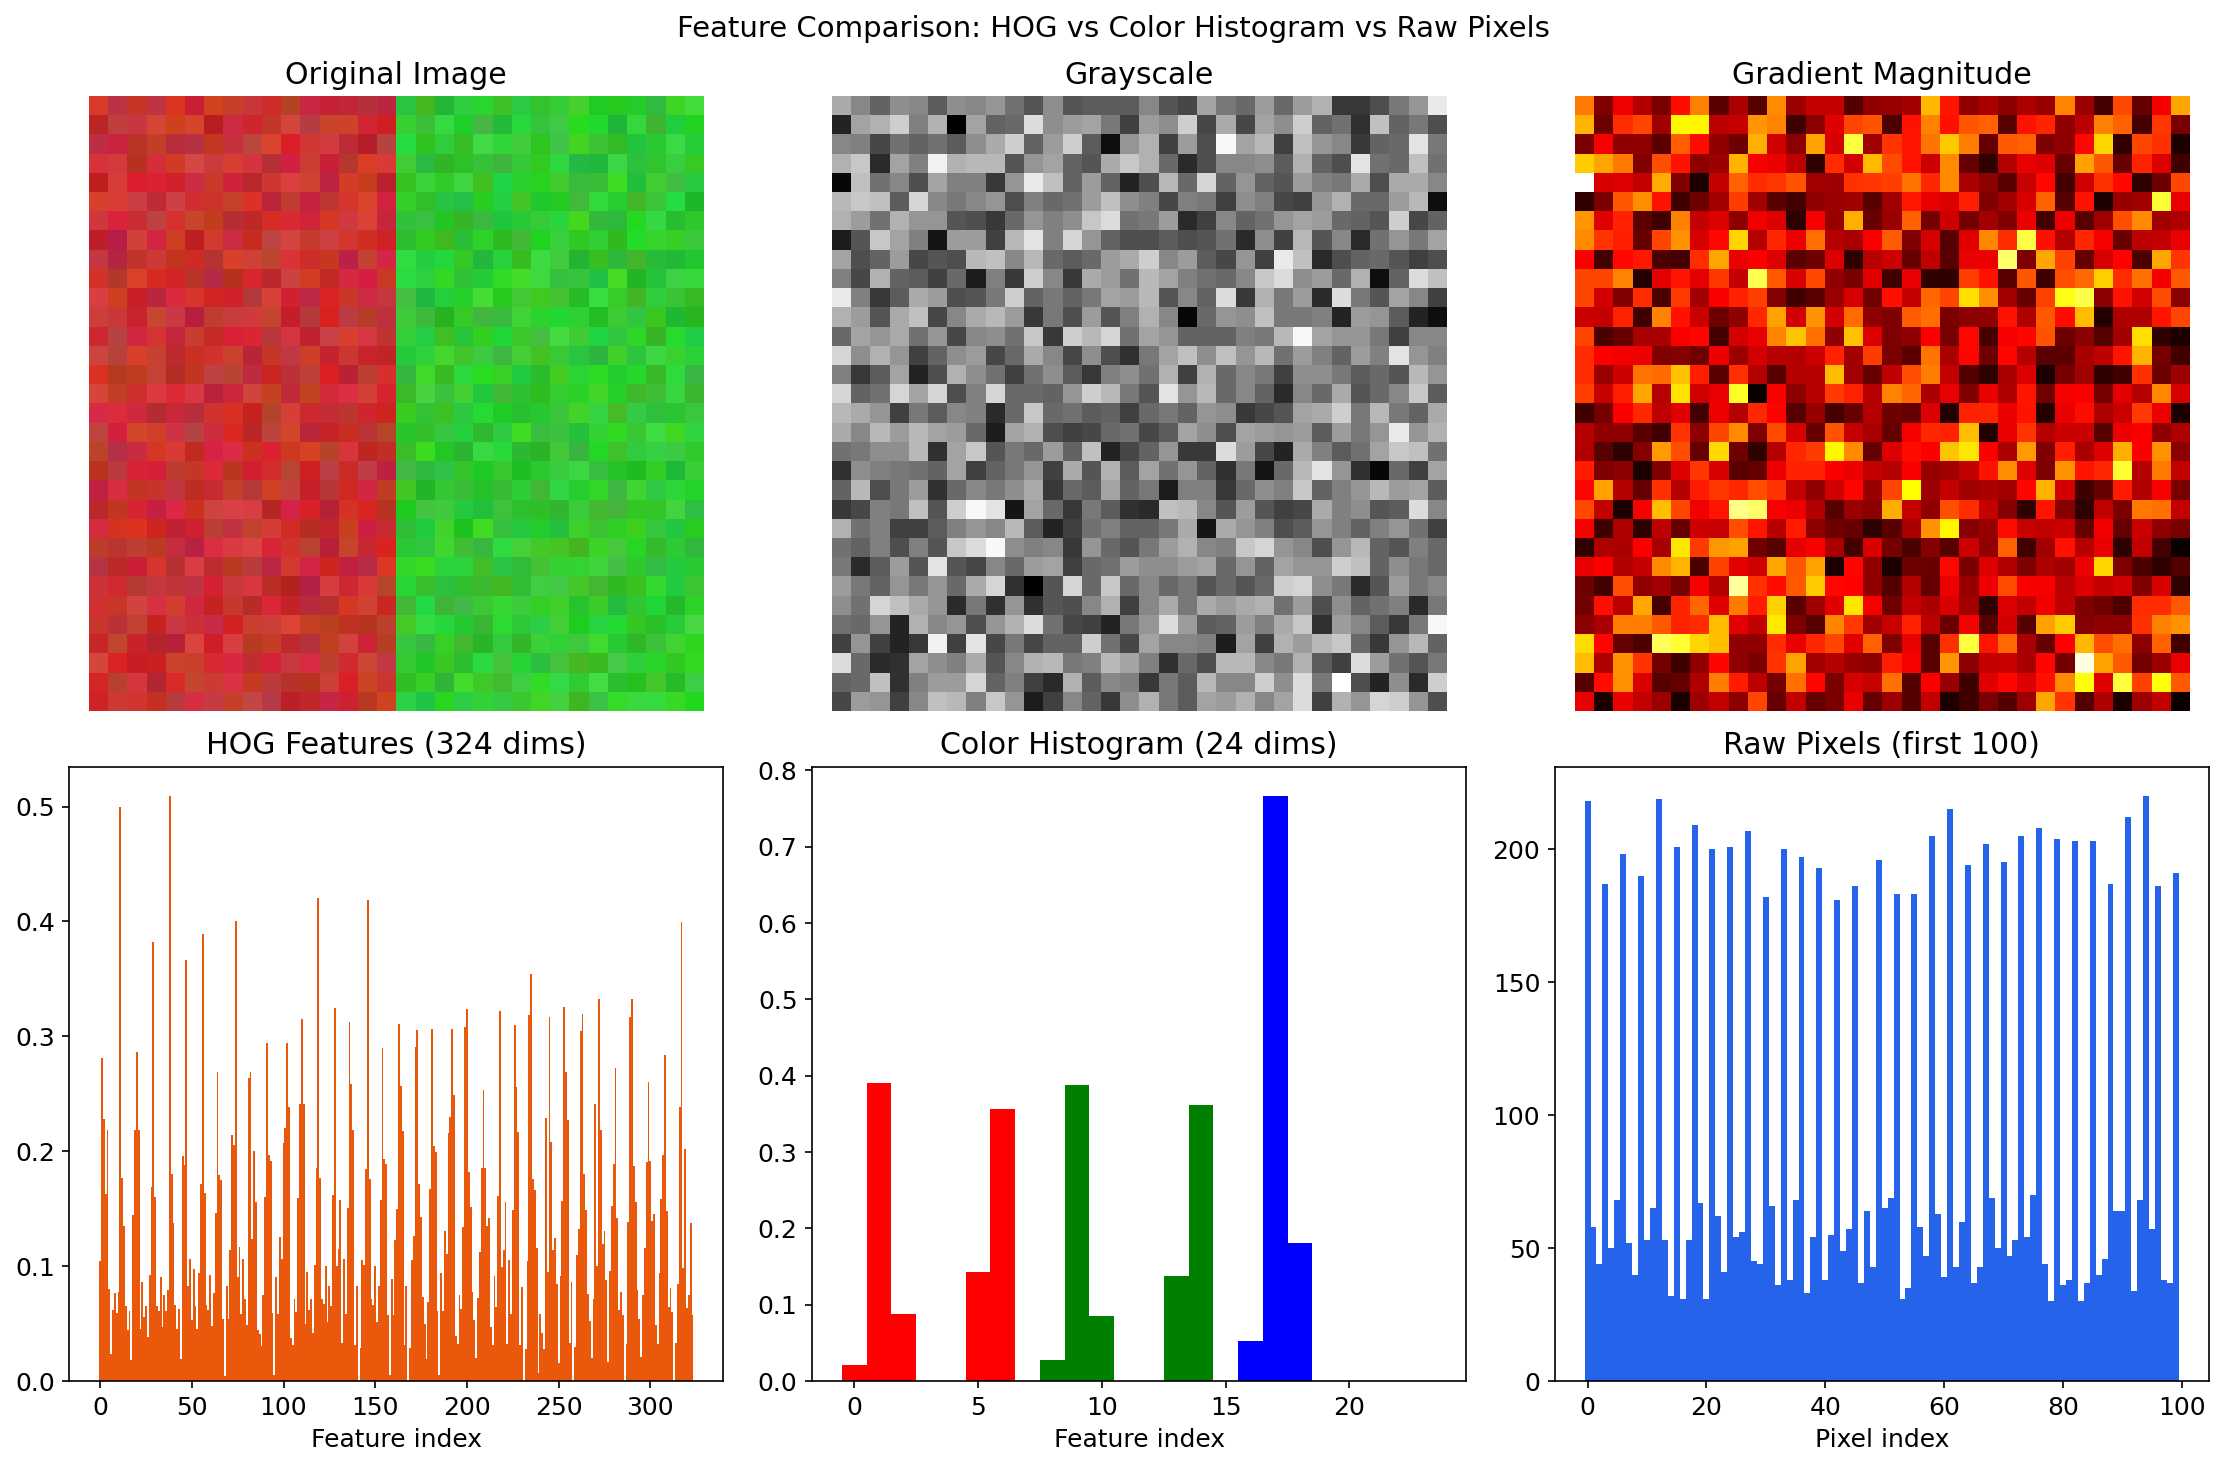

In [11]:
# Visualize features on a synthetic image
np.random.seed(42)

# Create a synthetic image with edges
img = np.zeros((32, 32, 3), dtype=np.uint8)
img[:, :16] = [200, 50, 50]  # left half red
img[:, 16:] = [50, 200, 50]  # right half green
# Add some noise
img = np.clip(img.astype(int) + np.random.randint(-20, 21, (32, 32, 3)), 0, 255).astype(np.uint8)

gray = np.mean(img, axis=2).astype(np.uint8)
hog_feat = compute_hog(gray, cell_size=8, n_bins=9, block_size=2)
color_hist = compute_color_histogram(img, n_bins=8)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# Original image
axes[0, 0].imshow(img)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')
# Grayscale
axes[0, 1].imshow(gray, cmap='gray')
axes[0, 1].set_title('Grayscale')
axes[0, 1].axis('off')
# Gradients
gx = np.zeros_like(gray, dtype=float)
gy = np.zeros_like(gray, dtype=float)
gx[:, :-1] = gray[:, 1:].astype(float) - gray[:, :-1].astype(float)
gy[:-1, :] = gray[1:, :].astype(float) - gray[:-1, :].astype(float)
mag = np.sqrt(gx**2 + gy**2)
axes[0, 2].imshow(mag, cmap='hot')
axes[0, 2].set_title('Gradient Magnitude')
axes[0, 2].axis('off')
# HOG histogram
axes[1, 0].bar(range(len(hog_feat)), hog_feat, color='#ea580c', width=1)
axes[1, 0].set_title(f'HOG Features ({len(hog_feat)} dims)')
axes[1, 0].set_xlabel('Feature index')
# Color histogram
axes[1, 1].bar(range(len(color_hist)), color_hist, 
              color=['r']*8 + ['g']*8 + ['b']*8, width=1)
axes[1, 1].set_title('Color Histogram (24 dims)')
axes[1, 1].set_xlabel('Feature index')
# Raw pixels
axes[1, 2].bar(range(100), img.reshape(-1)[:100], color='#2563eb', width=1)
axes[1, 2].set_title('Raw Pixels (first 100)')
axes[1, 2].set_xlabel('Pixel index')
plt.suptitle('Feature Comparison: HOG vs Color Histogram vs Raw Pixels', fontsize=14)
plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1: Feature comparison")

## 7. 分类实验：比较不同特征

使用线性 SVM 分类器，比较三种特征的分类效果：
1. 原始像素（3072 维）
2. HOG 特征（324 维）
3. 颜色直方图（24 维）

In [13]:
# Generate synthetic dataset for classification
def generate_image_dataset(n_per_class=50, n_classes=3, img_size=16):
    """Generate synthetic images with different patterns for each class."""
    np.random.seed(42)
    images = []
    labels = []
    for c in range(n_classes):
        for _ in range(n_per_class):
            img = np.random.randint(80, 180, (img_size, img_size, 3), dtype=np.uint8)
            if c == 0:  # horizontal stripes
                img[::2, :] += 50
            elif c == 1:  # vertical stripes
                img[:, ::2] += 50
            else:  # diagonal
                for i in range(img_size):
                    img[i, i] = 255
            images.append(img)
            labels.append(c)
    return np.array(images), np.array(labels)

np.random.seed(42)
images, labels = generate_image_dataset(n_per_class=80, n_classes=3, img_size=16)
print(f"Dataset: {images.shape}, Labels: {labels.shape}")

# Linear SVM classifier
class LinearSVM:
    def __init__(self, n_features, n_classes):
        self.W = np.random.randn(n_classes, n_features) * 0.01
    
    def train(self, X, y, lr=0.1, reg=1e-3, epochs=300):
        losses = []
        for _ in range(epochs):
            scores = X @ self.W.T
            margins = np.maximum(0, scores - scores[np.arange(len(y)), y][:, None] + 1)
            margins[np.arange(len(y)), y] = 0
            loss = np.sum(margins) / len(y) + reg * np.sum(self.W**2)
            
            mask = (margins > 0).astype(float)
            mask[np.arange(len(y)), y] = -np.sum(mask, axis=1)
            dW = mask.T @ X / len(y) + 2 * reg * self.W
            self.W -= lr * dW
            losses.append(loss)
        return losses
    
    def predict(self, X):
        return np.argmax(X @ self.W.T, axis=1)

# Extract features
def extract_raw_pixels(images):
    return images.reshape(len(images), -1).astype(float) / 255.0

def extract_hog_features(images):
    return np.array([compute_hog(img, cell_size=4, n_bins=9, block_size=2) for img in images])

def extract_color_hist(images):
    return np.array([compute_color_histogram(img, n_bins=8) for img in images])

# Split train/test
n = len(images)
idx = np.random.permutation(n)
n_train = int(0.8 * n)
train_idx, test_idx = idx[:n_train], idx[n_train:]

results = {}
for name, feat_fn in [('Raw Pixels', extract_raw_pixels), 
                       ('HOG', extract_hog_features),
                       ('Color Hist', extract_color_hist)]:
    X = feat_fn(images)
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]
    
    clf = LinearSVM(X_train.shape[1], 3)
    losses = clf.train(X_train, y_train, lr=0.1, epochs=300)
    train_acc = np.mean(clf.predict(X_train) == y_train)
    test_acc = np.mean(clf.predict(X_test) == y_test)
    results[name] = {'train_acc': train_acc, 'test_acc': test_acc, 'losses': losses}
    print(f"{name:12s}: train_acc={train_acc:.2%}, test_acc={test_acc:.2%}, feat_dim={X_train.shape[1]}")

Dataset: (240, 16, 16, 3), Labels: (240,)
Raw Pixels  : train_acc=100.00%, test_acc=100.00%, feat_dim=768
HOG         : train_acc=100.00%, test_acc=100.00%, feat_dim=324
Color Hist  : train_acc=76.04%, test_acc=58.33%, feat_dim=24


Visualization 2: Classification comparison


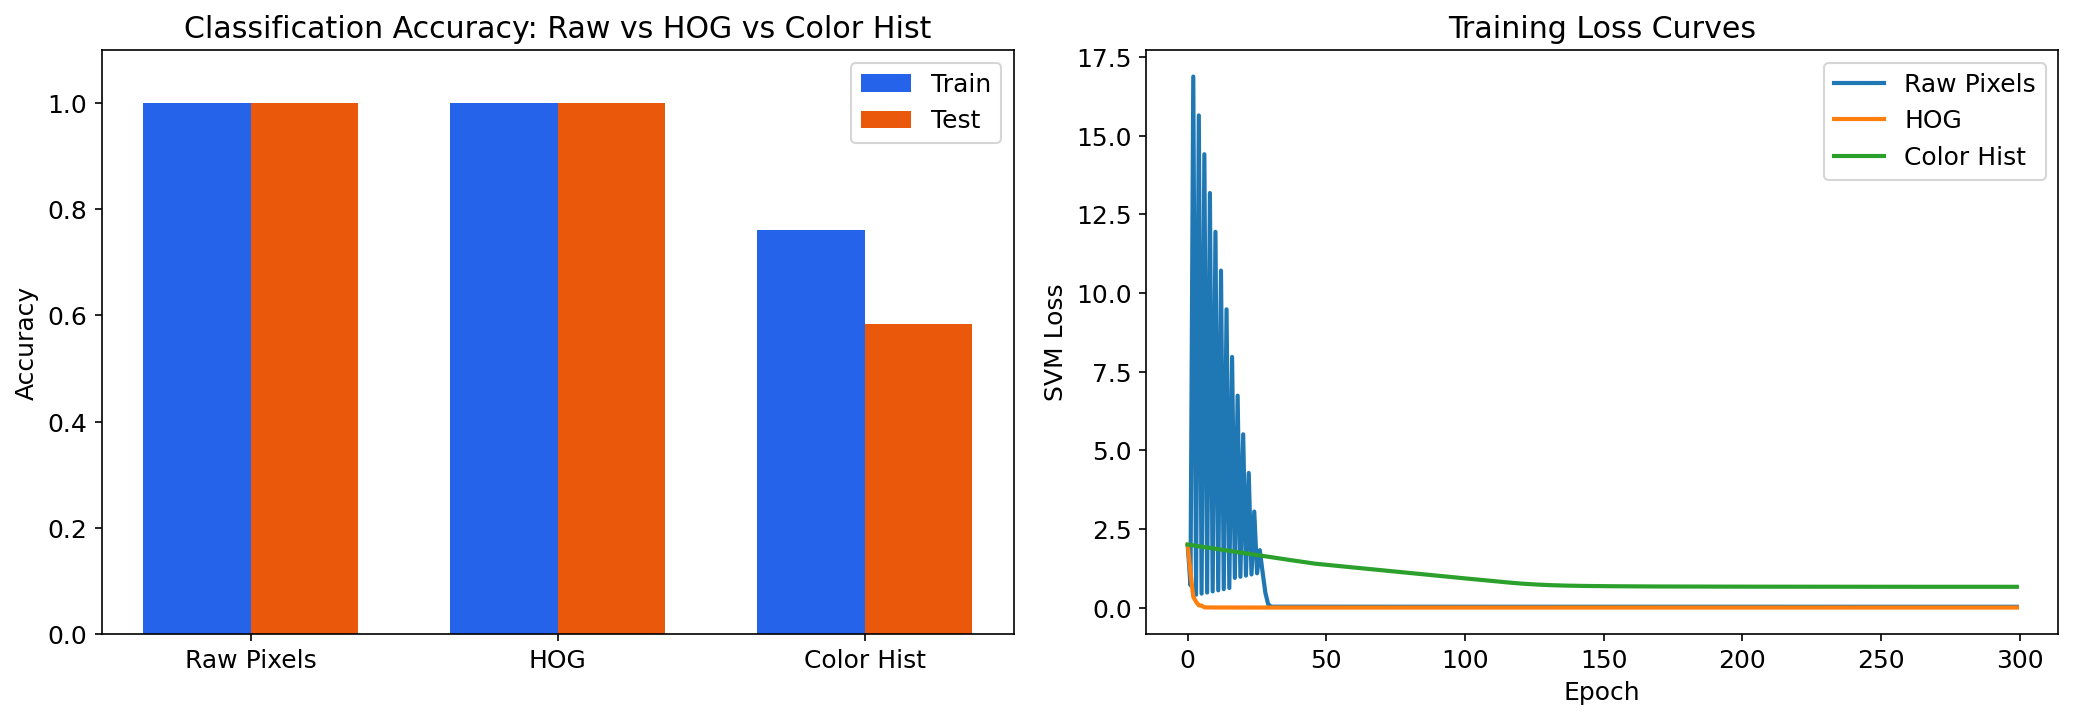

In [14]:
# Visualize classification results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes

# Accuracy comparison
names = list(results.keys())
train_accs = [results[n]['train_acc'] for n in names]
test_accs = [results[n]['test_acc'] for n in names]
x = np.arange(len(names))
w = 0.35
ax1.bar(x - w/2, train_accs, w, label='Train', color='#2563eb')
ax1.bar(x + w/2, test_accs, w, label='Test', color='#ea580c')
ax1.set_xticks(x)
ax1.set_xticklabels(names)
ax1.set_ylabel('Accuracy')
ax1.set_title('Classification Accuracy: Raw vs HOG vs Color Hist')
ax1.legend()
ax1.set_ylim(0, 1.1)

# Loss curves
for name in names:
    ax2.plot(results[name]['losses'], label=name, linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('SVM Loss')
ax2.set_title('Training Loss Curves')
ax2.legend()
plt.tight_layout()
plt.savefig('feature_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2: Classification comparison")

Visualization 3: Feature visualization per class


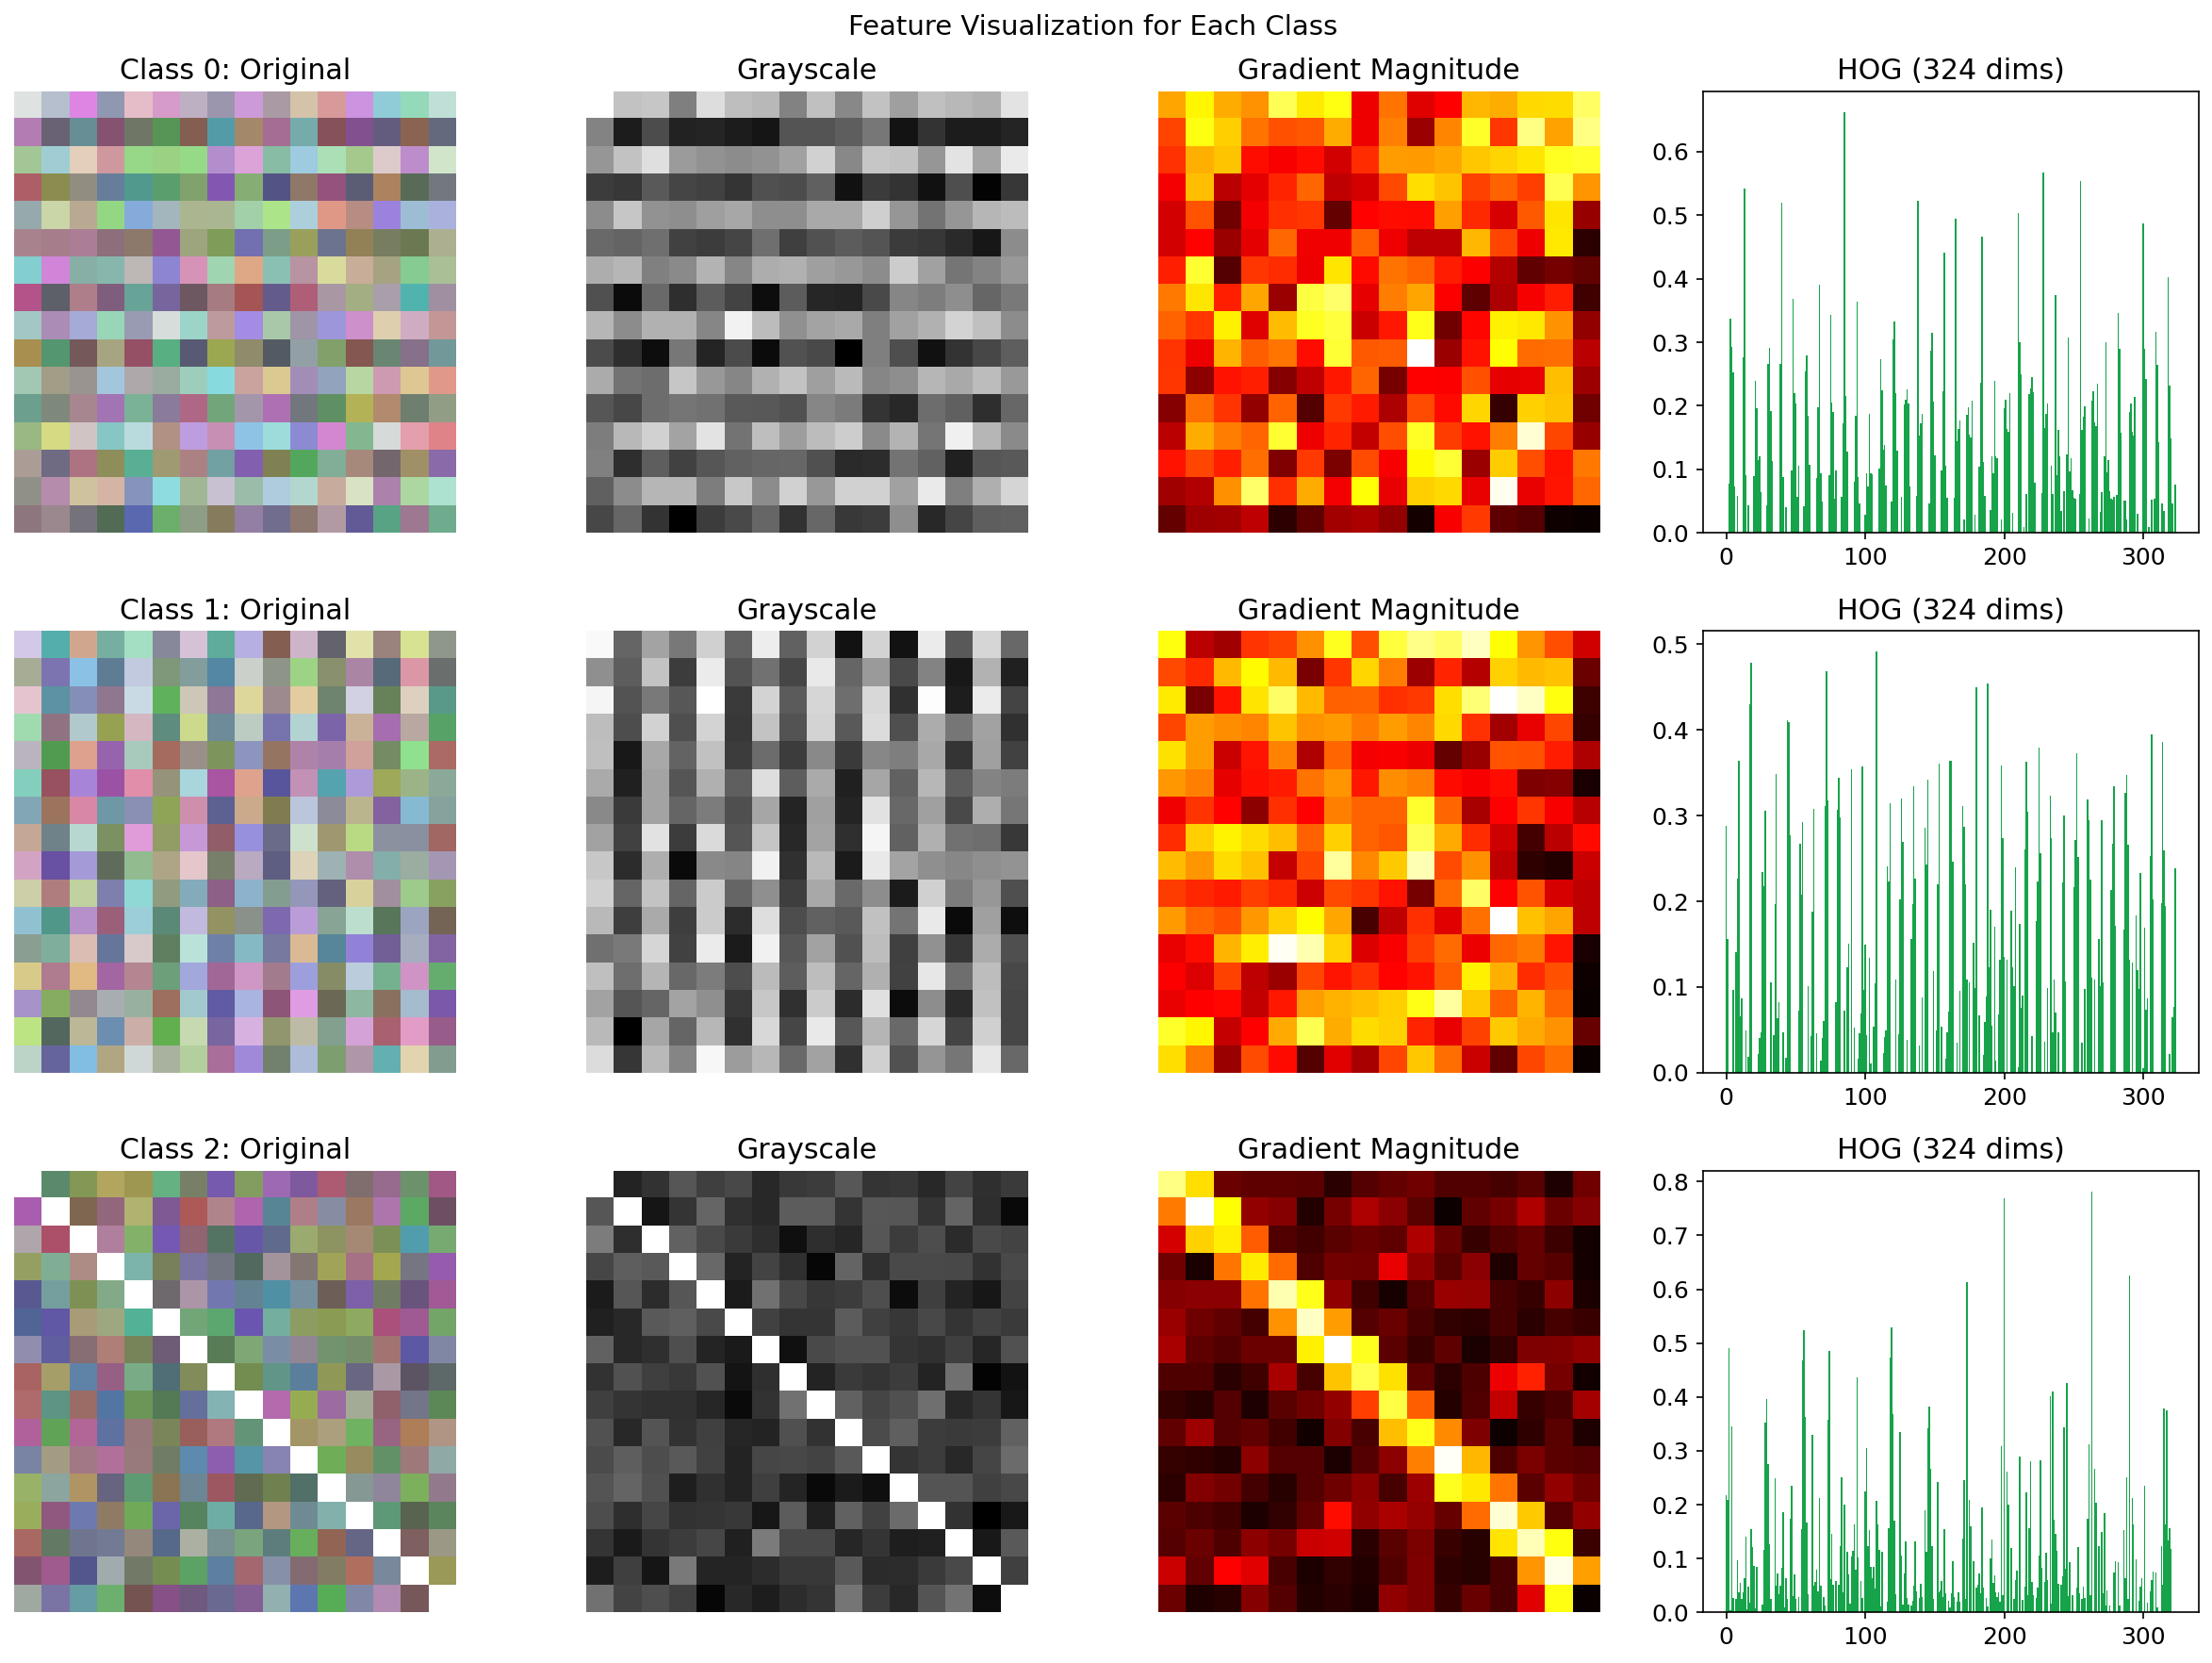

In [15]:
# Visualize sample images and their HOG features
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for c in range(3):
    idx = np.where(labels == c)[0][:1][0]
    img = images[idx]
    gray = np.mean(img, axis=2).astype(np.uint8)
    hog_feat = compute_hog(gray, cell_size=4, n_bins=9, block_size=2)
    
    axes[c, 0].imshow(img)
    axes[c, 0].set_title(f'Class {c}: Original')
    axes[c, 0].axis('off')
    
    axes[c, 1].imshow(gray, cmap='gray')
    axes[c, 1].set_title('Grayscale')
    axes[c, 1].axis('off')
    
    gx = np.zeros_like(gray, dtype=float)
    gy = np.zeros_like(gray, dtype=float)
    gx[:, :-1] = gray[:, 1:].astype(float) - gray[:, :-1].astype(float)
    gy[:-1, :] = gray[1:, :].astype(float) - gray[:-1, :].astype(float)
    mag = np.sqrt(gx**2 + gy**2)
    axes[c, 2].imshow(mag, cmap='hot')
    axes[c, 2].set_title('Gradient Magnitude')
    axes[c, 2].axis('off')
    
    axes[c, 3].bar(range(len(hog_feat)), hog_feat, color='#16a34a', width=1)
    axes[c, 3].set_title(f'HOG ({len(hog_feat)} dims)')

plt.suptitle('Feature Visualization for Each Class', fontsize=14)
plt.tight_layout()
plt.savefig('feature_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 3: Feature visualization per class")

## 8. 实验观察：特征维度与效果

### 关键发现

1. **HOG 优于原始像素**：HOG 编码了梯度方向信息，对光照变化更鲁棒
2. **颜色直方图适合颜色区分任务**：如果类别间颜色差异大，颜色直方图简单有效
3. **特征维度**：HOG (324) < 原始像素 (768) < 全像素，更紧凑
4. **深度学习的优势**：CNN 自动学习最优特征，远超手工设计

### HOG 的历史意义

HOG + SVM 曾是目标检测的标准方法（DPM, 2008-2012）。ImageNet 2012 之后，深度学习全面取代了手工特征。

## 9. SIFT 特征概念

### SIFT (Scale-Invariant Feature Transform)

[[Lowe, 2004]](https://link.springer.com/article/10.1023/B:VISI.0000029664.99615.94)

SIFT 是另一种经典特征，与 HOG 的区别：
- **HOG**：密集计算，覆盖整个图像区域
- **SIFT**：稀疏计算，只在关键点处提取

SIFT 的步骤：
1. 尺度空间极值检测（DoG）
2. 关键点定位
3. 方向分配
4. 关键点描述子（128 维）

SIFT 对尺度、旋转、光照变化都具有不变性，是传统 CV 最强大的特征之一。

Visualization 4: Feature dimension comparison


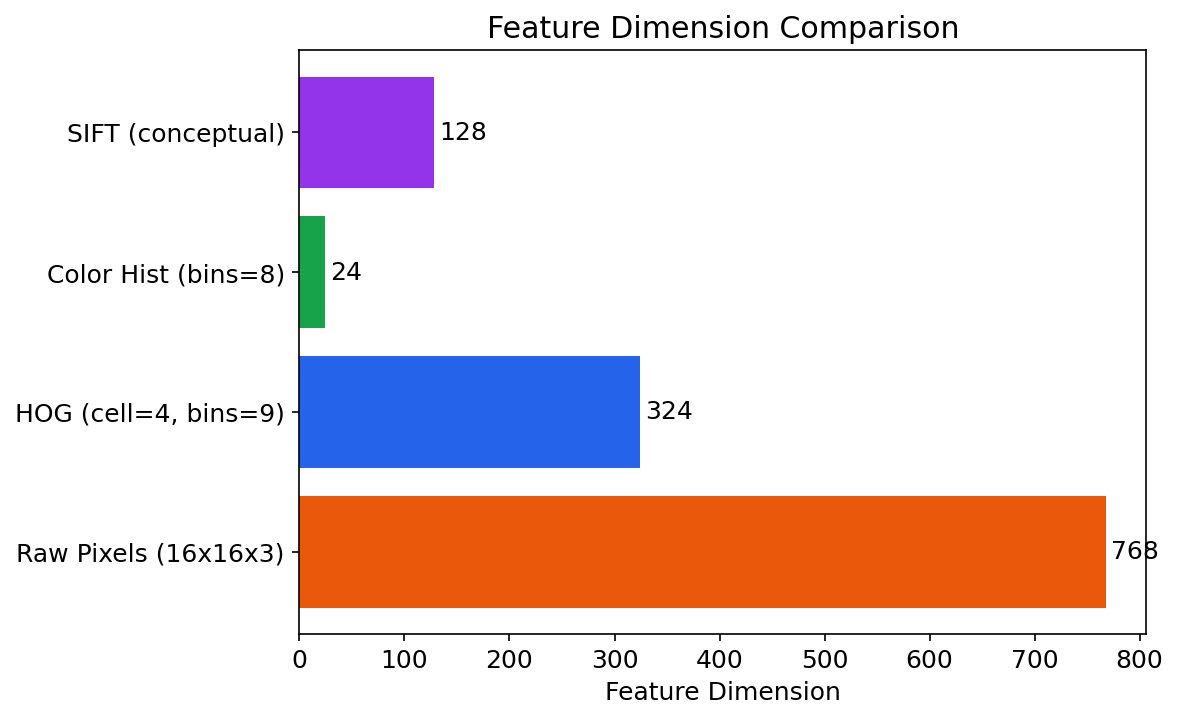

In [18]:
# Compare feature dimensions
features_info = {
    'Raw Pixels (16x16x3)': 768,
    'HOG (cell=4, bins=9)': 324,
    'Color Hist (bins=8)': 24,
    'SIFT (conceptual)': 128,  # per keypoint
}

fig, ax = plt.subplots(figsize=(8, 5))
names = list(features_info.keys())
dims = list(features_info.values())
bars = ax.barh(names, dims, color=['#ea580c', '#2563eb', '#16a34a', '#9333ea'])
ax.set_xlabel('Feature Dimension')
ax.set_title('Feature Dimension Comparison')
for bar, dim in zip(bars, dims):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            str(dim), va='center', fontsize=12)
plt.tight_layout()
plt.savefig('feature_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 4: Feature dimension comparison")

## 作业

### 作业 1：实现带插值的 HOG

当前 HOG 实现将梯度直接分配到最近的 bin。改进为**双线性插值**：将幅值按距离分配到相邻的两个 bin。

**提示**：对于角度 $\theta$ 和 bin 宽度 $w$：
- $b_1 = \lfloor \theta / w \rfloor$, $b_2 = b_1 + 1$
- $d_1 = \theta / w - b_1$, $d_2 = 1 - d_1$
- 贡献：$hist[b_1] += m \cdot d_2$, $hist[b_2] += m \cdot d_1$

In [20]:
# Homework 1: HOG with bilinear interpolation
def compute_hog_interpolated(image, cell_size=8, n_bins=9, block_size=2):
    """HOG with bilinear orientation interpolation."""
    if len(image.shape) == 3:
        image = np.mean(image, axis=2)
    
    H, W = image.shape
    gx = np.zeros_like(image, dtype=float)
    gy = np.zeros_like(image, dtype=float)
    gx[:, :-1] = image[:, 1:].astype(float) - image[:, :-1].astype(float)
    gy[:-1, :] = image[1:, :].astype(float) - image[:-1, :].astype(float)
    
    mag = np.sqrt(gx**2 + gy**2)
    angle = np.degrees(np.arctan2(gy, gx))
    angle[angle < 0] += 180
    
    n_cells_y = H // cell_size
    n_cells_x = W // cell_size
    cell_hist = np.zeros((n_cells_y, n_cells_x, n_bins))
    
    bin_width = 180.0 / n_bins
    
    for cy in range(n_cells_y):
        for cx in range(n_cells_x):
            cell_mag = mag[cy*cell_size:(cy+1)*cell_size, 
                           cx*cell_size:(cx+1)*cell_size]
            cell_ang = angle[cy*cell_size:(cy+1)*cell_size, 
                            cx*cell_size:(cx+1)*cell_size]
            # TODO: implement bilinear interpolation
            pass
    
    # Block normalization
    hog_features = []
    for by in range(n_cells_y - block_size + 1):
        for bx in range(n_cells_x - block_size + 1):
            block = cell_hist[by:by+block_size, bx:bx+block_size, :].ravel()
            norm = np.linalg.norm(block) + 1e-8
            hog_features.append(block / norm)
    
    return np.concatenate(hog_features)

# Test
np.random.seed(42)
test_img = np.random.randint(0, 256, (16, 16), dtype=np.uint8)
hog_simple = compute_hog(test_img, cell_size=4, n_bins=9, block_size=2)
# hog_interp = compute_hog_interpolated(test_img, cell_size=4, n_bins=9, block_size=2)
# assert hog_interp.shape == hog_simple.shape, "Feature dimension should match"
# assert np.all(hog_interp >= 0), "HOG values should be non-negative"
print("Homework 1 template ready. Implement bilinear interpolation.")

Homework 1 template ready. Implement bilinear interpolation.


### 作业 2：多尺度颜色直方图

实现多尺度颜色直方图：将图像分成 2×2 区域，每个区域分别计算颜色直方图，最后拼接。

In [22]:
# Homework 2: Multi-scale color histogram
def compute_multiscale_color_hist(image, n_bins=8, n_regions=2):
    """Compute multi-scale color histogram by splitting image into regions.
    
    Args:
        image: (H, W, 3) RGB image
        n_bins: bins per channel per region
        n_regions: split image into n_regions x n_regions
    
    Returns:
        hist: concatenated histograms from all regions
    """
    H, W, C = image.shape
    rh = H // n_regions
    rw = W // n_regions
    all_hist = []
    
    for i in range(n_regions):
        for j in range(n_regions):
            region = image[i*rh:(i+1)*rh, j*rw:(j+1)*rw]
            # TODO: compute color histogram for this region
            pass
    
    return np.concatenate(all_hist)

# Test
np.random.seed(42)
test_img = np.random.randint(0, 256, (16, 16, 3), dtype=np.uint8)
# hist = compute_multiscale_color_hist(test_img, n_bins=8, n_regions=2)
# assert len(hist) == 4 * 3 * 8, "Should have 4 regions x 3 channels x 8 bins"
print("Homework 2 template ready. Implement multi-scale color histogram.")

Homework 2 template ready. Implement multi-scale color histogram.


### 作业 3：特征融合

将 HOG 和颜色直方图拼接为联合特征，观察是否比单一特征效果更好。

In [24]:
# Homework 3: Feature fusion
def extract_fused_features(images):
    """Extract fused HOG + color histogram features."""
    features = []
    for img in images:
        # TODO: concatenate HOG and color histogram features
        hog = compute_hog(img, cell_size=4, n_bins=9, block_size=2)
        chist = compute_color_histogram(img, n_bins=8)
        # fused = np.concatenate([hog, chist])
        pass
    return np.array(features)

# Test
np.random.seed(42)
# fused = extract_fused_features(images)
# X_fused_train = fused[train_idx]
# clf_fused = LinearSVM(X_fused_train.shape[1], 3)
# losses = clf_fused.train(X_fused_train, y_train, lr=0.1, epochs=300)
# fused_acc = np.mean(clf_fused.predict(fused[test_idx]) == y_test)
# assert fused_acc >= results['HOG']['test_acc'], "Fused should be >= HOG alone"
print("Homework 3 template ready. Implement feature fusion.")

Homework 3 template ready. Implement feature fusion.


## 小结

| 特征 | 维度 | 捕捉信息 | 优点 | 局限 |
|------|------|----------|------|------|
| **原始像素** | 高 | 所有信息 | 无信息丢失 | 维度高、无空间结构 |
| **HOG** | 中 | 边缘/形状 | 光照不变、紧凑 | 颜色信息丢失 |
| **颜色直方图** | 低 | 颜色分布 | 极紧凑、快速 | 无空间信息 |
| **SIFT** | 中 | 局部关键点 | 尺度/旋转不变 | 稀疏、需关键点检测 |

**核心洞察**：手工特征是对图像的特定「视角」，各有侧重但都不完整。深度学习通过端到端学习自动发现最优特征表示，这是其超越传统方法的根本原因。

## 参考文献

1. [[Dalal & Triggs, 2005]](https://ieeexplore.ieee.org/document/1467360) Dalal & Triggs. *Histograms of Oriented Gradients for Human Detection*. CVPR 2005.
2. [[Lowe, 2004]](https://link.springer.com/article/10.1023/B:VISI.0000029664.99615.94) Lowe. *Distinctive Image Features from Scale-Invariant Keypoints*. IJCV 2004.
3. **CS231n Assignment 1** - [Feature Engineering](https://cs231n.github.io/assignments2021/assignment1/)
4. [[Felzenszwalb et al., 2010]](https://cs.brown.edu/people/pfelzens/papers/lat-mid.pdf) Felzenszwalb et al. *Object Detection with Discriminatively Trained Part Based Models*. PAMI 2010.

---

> 本节内容参考 [Stanford CS231n Assignment 1 Q4](https://cs231n.github.io/assignments2021/assignment1/)

---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[jariasf/CS231n](https://github.com/jariasf/CS231n)** (486 stars): CS231n 完整作业解答（KNN、SVM、Softmax、特征工程）
  - 仓库地址: https://github.com/jariasf/CS231n

- **[rishabh-16/cs231n-2019-assignments](https://github.com/rishabh-16/cs231n-2019-assignments)** (212 stars): 2019版 CS231n 作业 PyTorch+TensorFlow 解答
  - 仓库地址: https://github.com/rishabh-16/cs231n-2019-assignments

- **[amanchadha/stanford-cs231n-assignments-2020](https://github.com/amanchadha/stanford-cs231n-assignments-2020)** (175 stars): 2020春季 CS231n 完整作业解答
  - 仓库地址: https://github.com/amanchadha/stanford-cs231n-assignments-2020

> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现.